<a href="https://colab.research.google.com/github/turryhit/data-analytics-public/blob/main/2026_04_07_Class13_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the data

In [ ]:
import pandas as pd

In [ ]:
URL = "https://www.kaggle.com/api/v1/datasets/download/hesh97/titanicdataset-traincsv"
train = pd.read_csv(URL, compression="zip")

In [ ]:
train.shape

(891, 12)

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Cleaning the data

In [ ]:
import seaborn as sns

<Axes: >

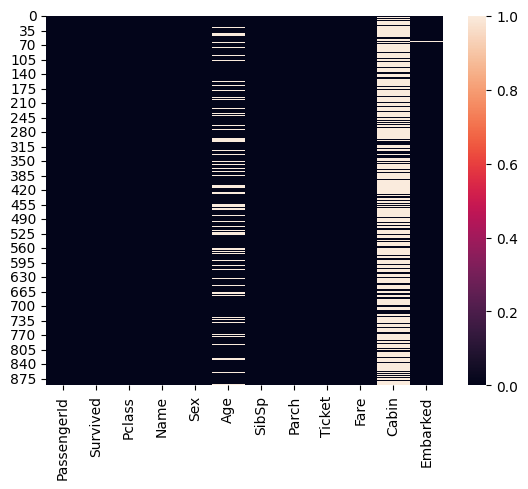

In [ ]:
# We take a look at what columns have null values, and how much
# We use a heatmap for a visual representation of this
sns.heatmap(train.isnull())

In [ ]:
# We can reach the same conclusion by looking as isnull().sum()
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## EDA

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Survived', ylabel='count'>

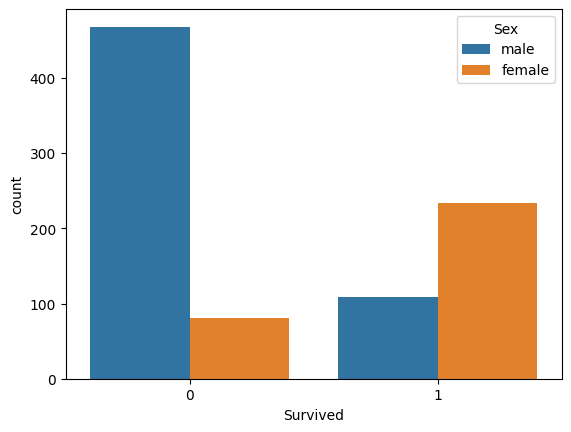

In [ ]:
# We take a look at the impact of specific factors on chances of survival
sns.countplot(data=train, x="Survived", hue="Sex")

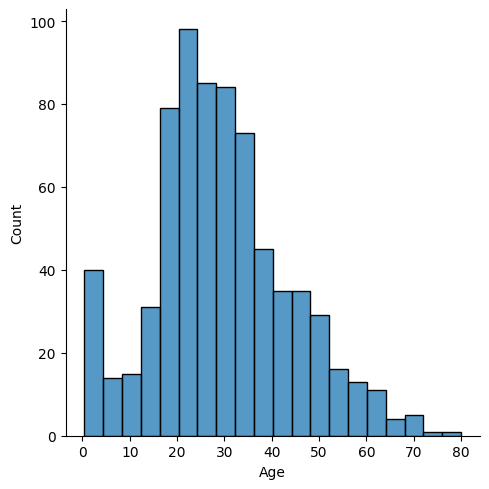

In [ ]:
sns.displot(train["Age"].dropna())

<Axes: xlabel='Pclass', ylabel='Age'>

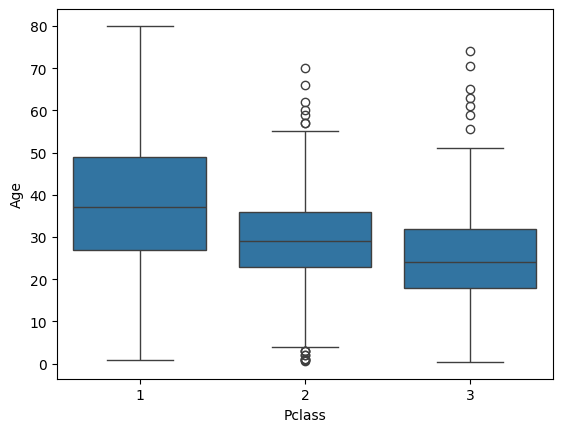

In [ ]:
sns.boxplot(x="Pclass", y="Age", data=train)

### Sidenote on apply()

In [ ]:
# We can create a function to apply to every row
def infer_gender(row: pd.Series):
  name = row["Name"].lower()
  if "mr." in name:
    return "M"
  elif "mrs." in name:
    return "F"
  elif "miss." in name:
    return "F"
  elif "rev." in name:
    return "M"
  elif "master." in name:
    return "M"
  return pd.NA


In [ ]:
# We apply the function "infer_gender" to every row
train["gender"] = train.apply(infer_gender, axis=1)

In [ ]:
train = train.drop(columns=["gender"])

### Data Imputation

In [ ]:
train[train["Pclass"] == 3]["Age"].mean()

np.float64(25.14061971830986)

In [ ]:
from pandas.core.dtypes.missing import isnull
# Let's define the function to impute the age
def impute_age(row):
  age = row["Age"]
  pclass = row["Pclass"]

  if pd.isnull(age):
    # The value of age is null, we need to impute it
    if pclass == 1:
      return 37
    elif pclass == 2:
      return 29
    elif pclass == 3:
      return 25
  else:
    return age

In [ ]:
# We impute the age column to fill in the gaps
train["Age"] = train.apply(impute_age, axis=1)

In [ ]:
# We check that the Age column no longer has NaN/null values
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# We drop the cabin column
train.drop(columns=["Cabin"], inplace=True)

In [ ]:
# Lastly, we drop all rows that contain NaN values
train.dropna(inplace=True)

In [ ]:
sex = pd.get_dummies(train["Sex"], drop_first=True, dtype=int)

In [ ]:
#C = Cherbourg (France) Q = Queenstown (now Cobh, Ireland) S = Southampton (UK)
train["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
embark = pd.get_dummies(train["Embarked"], drop_first=True, dtype=int)

In [ ]:
# We drop the remaining columns that are not numeric
train.drop(columns=["Sex", "Embarked", "Name", "Ticket"], inplace=True)

In [ ]:
train = pd.concat([train, sex, embark], axis=1)

In [ ]:
train

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,1,0,1
887,888,1,1,19.0,0,0,30.0000,0,0,1
888,889,0,3,25.0,1,2,23.4500,0,0,1
889,890,1,1,26.0,0,0,30.0000,1,0,0


# Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    train.drop(columns=["Survived"]),
    train["Survived"],
    test_size=0.30,
    random_state=101
    )

In [ ]:
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression()

In [ ]:
logmodel.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
predictions = logmodel.predict(X_test)

In [ ]:
predictions

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       163
           1       0.81      0.63      0.71       104

    accuracy                           0.80       267
   macro avg       0.81      0.77      0.78       267
weighted avg       0.80      0.80      0.80       267



In [ ]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q',
       'S'],
      dtype='object')

In [ ]:
dummy_user = {'PassengerId': 999,
              'Pclass': 3,
              'Age': 19,
              'SibSp': 0,
              'Parch': 0,
              'Fare': 2.0,
              'male': 0,
              'Q': 0,
              'S': 0}
dummy_df = pd.DataFrame([dummy_user])

In [ ]:
logmodel.predict(dummy_df)

array([1])

In [ ]:
import numpy as np

coef_df = pd.DataFrame({
    'feature': train.drop("Survived", axis=1).columns,
    'coefficient': logmodel.coef_[0],
    'abs_coefficient': np.abs(logmodel.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

In [ ]:
coef_df

,feature,coefficient,abs_coefficient
6,male,-2.396099,2.396099
1,Pclass,-0.327152,0.327152
4,Parch,-0.303448,0.303448
7,Q,0.131452,0.131452
8,S,0.081207,0.081207
3,SibSp,-0.049803,0.049803
5,Fare,0.010894,0.010894
2,Age,-0.004667,0.004667
0,PassengerId,0.000855,0.000855
